In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)

gene_trait_df = gene_trait_df.select(['region', 'phenotype', 'loftee_corr_dir'])
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,loftee_corr_dir
str,str,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",-1.0
"""ENSG00000101439""","""cystatin_c_int""",-1.0
"""ENSG00000149948""","""standing_height_int""",-1.0
"""ENSG00000205846""","""aspartate_aminotransferase_int""",1.0
…,…,…
"""ENSG00000104408""","""mean_corpuscular_volume_int""",-1.0
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",1.0


In [3]:
# EUR unrelated individuals

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/sample_lists/unrelated_cauc_samples_3rd_degree.csv -o /home/dnanexus/data_dir/

unrel_eur_samples = pl.read_csv('/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv')['eid'].cast(pl.Utf8).to_list()
unrel_eur_samples[:5]

Error: path "/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv"
already exists but -f/--overwrite was not set


['1000020', '1000107', '1000161', '1000172', '1000221']

In [4]:
from scipy.special import ndtri

c = 3/8  # Blom's constant for inverse normal transformation (prevents infinite values at the tails)

# Download phenotypes: covariates and PRS corrected
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/phenotypes/corrected_cov_PRS_traits_EUR.parquet -o /home/dnanexus/data_dir/

phenos = (
    pl.read_parquet('/home/dnanexus/data_dir/corrected_cov_PRS_traits_EUR.parquet')
    .rename({'individual':'sample'})
    .filter(pl.col('sample').is_in(unrel_eur_samples))
)

# phenos
long_phenos_int = (
    phenos
    .unpivot(
        index='sample',
        on=gene_trait_df['phenotype'].unique().to_list(),
        variable_name='phenotype',
        value_name='pheno_value'
    )
    .drop_nulls()

    .lazy()  # Use Lazy mode for better memory/query optimization
    .with_columns(
        # Calculate rank and group size using native Rust engine
        r = pl.col("pheno_value").rank().over("phenotype"),
        n = pl.len().over("phenotype")
    )
    .with_columns(
        # Calculate the INT value calling ndtri ONCE on the whole column
        pheno_value_int = ((pl.col("r") - c) / (pl.col("n") - 2*c + 1)).map_batches(ndtri)
    )
    .drop(["r", "n", "pheno_value"]) # Clean up temporary columns

    .join(
        gene_trait_df.lazy(),
        on='phenotype',
        how='inner'
    )
    .collect()
)

print(long_phenos_int['phenotype'].value_counts(sort=True))
long_phenos_int

[===========================================================>] Completed 1,717,336,582 of 1,717,336,582 bytes (100%) /home/dnanexus/data_dir/corrected_cov_PRS_traits_EUR.parquett
shape: (96, 2)
┌─────────────────────────────────┬──────────┐
│ phenotype                       ┆ count    │
│ ---                             ┆ ---      │
│ str                             ┆ u64      │
╞═════════════════════════════════╪══════════╡
│ standing_height_int             ┆ 29114316 │
│ mean_platelet_thrombocyte_volu… ┆ 9926523  │
│ sitting_height_int              ┆ 9444350  │
│ mean_corpuscular_haemoglobin_i… ┆ 7720713  │
│ cystatin_c_int                  ┆ 7224160  │
│ …                               ┆ …        │
│ trunk_fat_mass_int              ┆ 372061   │
│ creatinine_enzymatic_in_urine_… ┆ 368060   │
│ mean_corpuscular_haemoglobin_c… ┆ 367651   │
│ age_started_wearing_glasses_or… ┆ 338512   │
│ testosterone_int                ┆ 327366   │
└─────────────────────────────────┴──────────┘


sample,phenotype,pheno_value_int,region,loftee_corr_dir
str,str,f64,str,f64
"""1000020""","""leg_fat_percentage_left_int""",-0.903481,"""ENSG00000173064""",1.0
"""1000020""","""leg_fat_percentage_left_int""",-0.903481,"""ENSG00000174231""",-1.0
"""1000020""","""leg_fat_percentage_left_int""",-0.903481,"""ENSG00000134294""",1.0
"""1000107""","""leg_fat_percentage_left_int""",-0.968523,"""ENSG00000173064""",1.0
"""1000107""","""leg_fat_percentage_left_int""",-0.968523,"""ENSG00000174231""",-1.0
…,…,…,…,…
"""2277715""","""mean_sphered_cell_volume_int""",0.815314,"""ENSG00000213398""",1.0
"""2277715""","""mean_sphered_cell_volume_int""",0.815314,"""ENSG00000156453""",1.0
"""2277715""","""mean_sphered_cell_volume_int""",0.815314,"""ENSG00000164163""",1.0


In [5]:
long_phenos_int.filter(pl.col('phenotype')=='standing_height_int').select(pl.col('pheno_value_int').std())

pheno_value_int
f64
0.999991


In [6]:
mac = 20

RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_DIR}/{ANNO_FILE}

id_list = (
    pl.scan_parquet(f'{LOCAL_DIR}/{ANNO_FILE}')
    .filter(
        pl.col('region').is_in(gene_trait_df.select('region').unique().to_series()),
        pl.col('mac_ukb')<=mac,
        pl.col('loftee_hc')==1,
    )
    .select(['id', 'region'])
    .unique()
    .collect()
)

id_list

[===========================================================>] Completed 7,370,308,270 of 7,370,308,270 bytes (100%) /home/dnanexus/data_dir//annotations_fillna_ukbgym_with_mane.parquett


/tmp/ipykernel_9684/2409906056.py:19: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region
str,str
"""chr5:154803289:G:A""","""ENSG00000155506"""
"""chr12:103745271:C:T""","""ENSG00000136011"""
"""chr18:21838469:TAGAAGTG:T""","""ENSG00000101752"""
"""chr16:791198:G:A""","""ENSG00000127586"""
"""chr18:21847126:G:A""","""ENSG00000101752"""
…,…
"""chr5:76695520:A:T""","""ENSG00000145703"""
"""chr16:74644710:AG:A""","""ENSG00000168411"""
"""chr7:92080102:CAGAG:C""","""ENSG00000127914"""


In [7]:
# Download genotype (long gt) file
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/gt_long.parquet -o /home/dnanexus/data_dir/

long_gt = (
    pl.scan_parquet('/home/dnanexus/data_dir/gt_long.parquet')
    .select(['id', 'sample', 'gt'])
    .filter(pl.col('sample').is_in(unrel_eur_samples))

    # Step 1: Semi join to filter down to only relevant variants
    .join(
        id_list.select('id').unique().lazy(),
        on='id',
        how='semi',
    )

    # Step 2: Inner join to bring in region then compute burden
    .join(
        id_list.lazy(), 
        on='id', 
        how='inner'
    )
    .group_by(['region', 'sample'])
    .agg(
        burden=pl.col('gt').sum().cast(pl.Int32)
    )
    
    .collect(engine='streaming')
)

long_gt

[===========================================================>] Completed 27,974,638,284 of 27,974,638,284 bytes (100%) /home/dnanexus/data_dir/gt_long.parquett==============================================>             ] Downloaded 21,743,271,936 of 27,974,638,284 bytes (77%) /home/dnanexus/data_dir/gt_long.parquet


region,sample,burden
str,str,i32
"""ENSG00000198604""","""4282858""",1
"""ENSG00000119596""","""5944597""",1
"""ENSG00000169856""","""5454695""",1
"""ENSG00000103657""","""5884068""",1
"""ENSG00000196296""","""3167349""",1
…,…,…
"""ENSG00000165124""","""1161245""",1
"""ENSG00000165124""","""1743870""",1
"""ENSG00000165124""","""1752607""",1


In [8]:
loftee_pheno_region = (
    long_phenos_int
    .join(
        long_gt,
        on=['sample', 'region'],
        how='inner'
    )
    .with_columns(
        pheno_value_dircorr = pl.col('pheno_value_int')*pl.col('loftee_corr_dir'),
    )
    .group_by(['region', 'burden'])
    .agg(
        mean_pheno_value_dircorr = pl.col('pheno_value_dircorr').mean(),
        std_pheno_value_dircorr = pl.col('pheno_value_dircorr').std(),
        median_pheno_value_dircorr = pl.col('pheno_value_dircorr').median(),
        n_samples = pl.count()
    )
    .with_columns(
        burden_categories = pl.col('burden').cast(pl.Utf8).cast(pl.Categorical)
    )
)

loftee_pheno_region

/tmp/ipykernel_9684/280202672.py:16: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)


region,burden,mean_pheno_value_dircorr,std_pheno_value_dircorr,median_pheno_value_dircorr,n_samples,burden_categories
str,i32,f64,f64,f64,u64,cat
"""ENSG00000163554""",2,0.222762,1.107596,0.288577,4,"""2"""
"""ENSG00000156802""",2,0.025064,0.673805,0.025064,2,"""2"""
"""ENSG00000128641""",2,0.309521,null,0.309521,1,"""2"""
"""ENSG00000067900""",1,0.536038,0.997641,0.607405,58,"""1"""
"""ENSG00000152270""",1,0.34451,0.996659,0.327393,229,"""1"""
…,…,…,…,…,…,…
"""ENSG00000165029""",1,1.887738,0.949651,2.021194,221,"""1"""
"""ENSG00000119772""",2,-0.455463,1.865518,0.099181,4,"""2"""
"""ENSG00000162551""",2,1.860411,null,1.860411,1,"""2"""


In [9]:
loftee_pheno_region.write_parquet('/home/dnanexus/data_dir/mean_loftee_phenotype_per_region.parquet')

!dx upload /home/dnanexus/data_dir/mean_loftee_phenotype_per_region.parquet  --path project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/

[===========================================================>] Uploaded 30,973 of 30,973 bytes (100%) /home/dnanexus/data_dir/mean_loftee_phenotype_per_region.parquet
ID                                file-J6P2xZjJg0yB8p05Y4g6pjGf
Class                             file
Project                           project-Gyp4fvjJg0yFZ374KvP9bGFJ
Folder                            /processed_data/ukbgym
Name                              mean_loftee_phenotype_per_region.parquet
State                             closing
Visibility                        visible
Types                             -
Properties                        -
Tags                              -
Outgoing links                    -
Created                           Tue Feb 24 23:05:55 2026
Created by                        shubhankar
 via the job                      job-J6P2Y68Jg0y8Z7y3806PXzQY
Last modified                     Tue Feb 24 23:05:56 2026
Media type                        
archivalState                     "live"
c

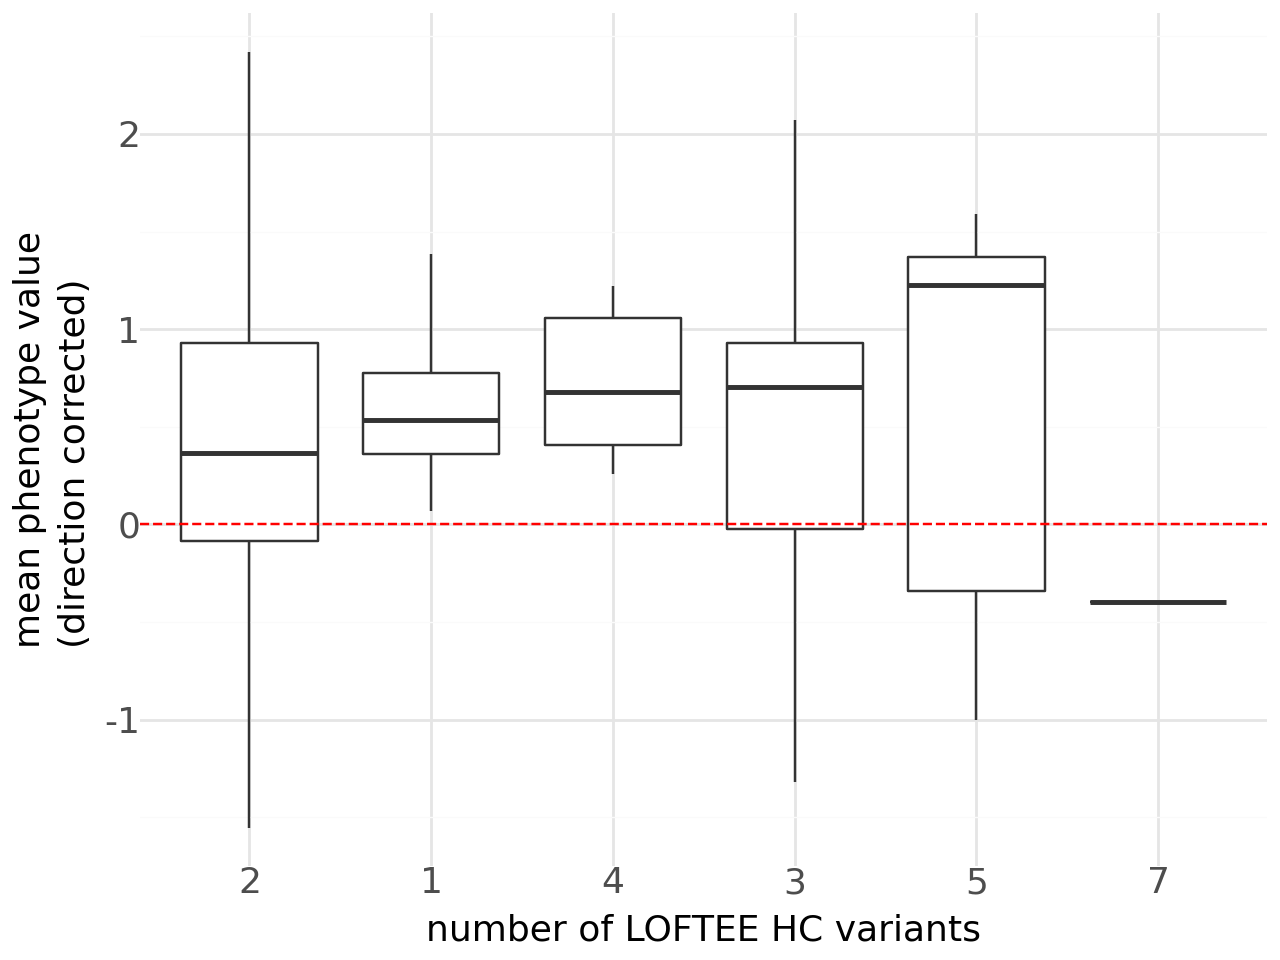

In [10]:
(
    ggplot(
        loftee_pheno_region, 
        aes(x='burden_categories', y='mean_pheno_value_dircorr')
    )
    + geom_boxplot(outlier_shape=None)
    + geom_hline(yintercept=0, linetype='dashed', color='red')
    + labs(
        x = 'number of LOFTEE HC variants',
        y = 'mean phenotype value\n(direction corrected)'
    )
    + theme_minimal()
    + theme(
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [11]:
loftee_pheno_avg_region = (
    loftee_pheno_region
    .group_by(['burden_categories'])
    .agg(
        n_individuals = pl.len().cast(pl.Int32),
        mean_pheno_value = pl.col('mean_pheno_value_dircorr').mean().cast(pl.Float32),
        std_pheno_value = pl.col('mean_pheno_value_dircorr').std().cast(pl.Float32),
        ci_quant_lower = pl.col('mean_pheno_value_dircorr').quantile(0.025).cast(pl.Float32),
        ci_quant_upper = pl.col('mean_pheno_value_dircorr').quantile(0.975).cast(pl.Float32),
    )
    .with_columns(
        ci_se_lower = pl.col('mean_pheno_value') - 1.96 * (pl.col('std_pheno_value') / pl.col('n_individuals').sqrt()),
        ci_se_upper = pl.col('mean_pheno_value') + 1.96 * (pl.col('std_pheno_value') / pl.col('n_individuals').sqrt())
    )
)

loftee_pheno_avg_region

burden_categories,n_individuals,mean_pheno_value,std_pheno_value,ci_quant_lower,ci_quant_upper,ci_se_lower,ci_se_upper
cat,i32,f32,f32,f32,f32,f64,f64
"""3""",69,0.450169,0.875729,-1.318539,1.936442,0.243535,0.656802
"""2""",274,0.448898,0.932357,-1.318035,2.51763,0.338499,0.559296
"""1""",670,0.634546,0.46483,0.153999,1.909485,0.599348,0.669743
"""5""",5,0.569518,1.163306,-1.000978,1.589464,-0.450164,1.589201
"""7""",1,-0.396249,null,-0.396249,-0.396249,null,null
"""4""",14,0.863245,0.595248,0.260247,2.128207,0.551435,1.175055


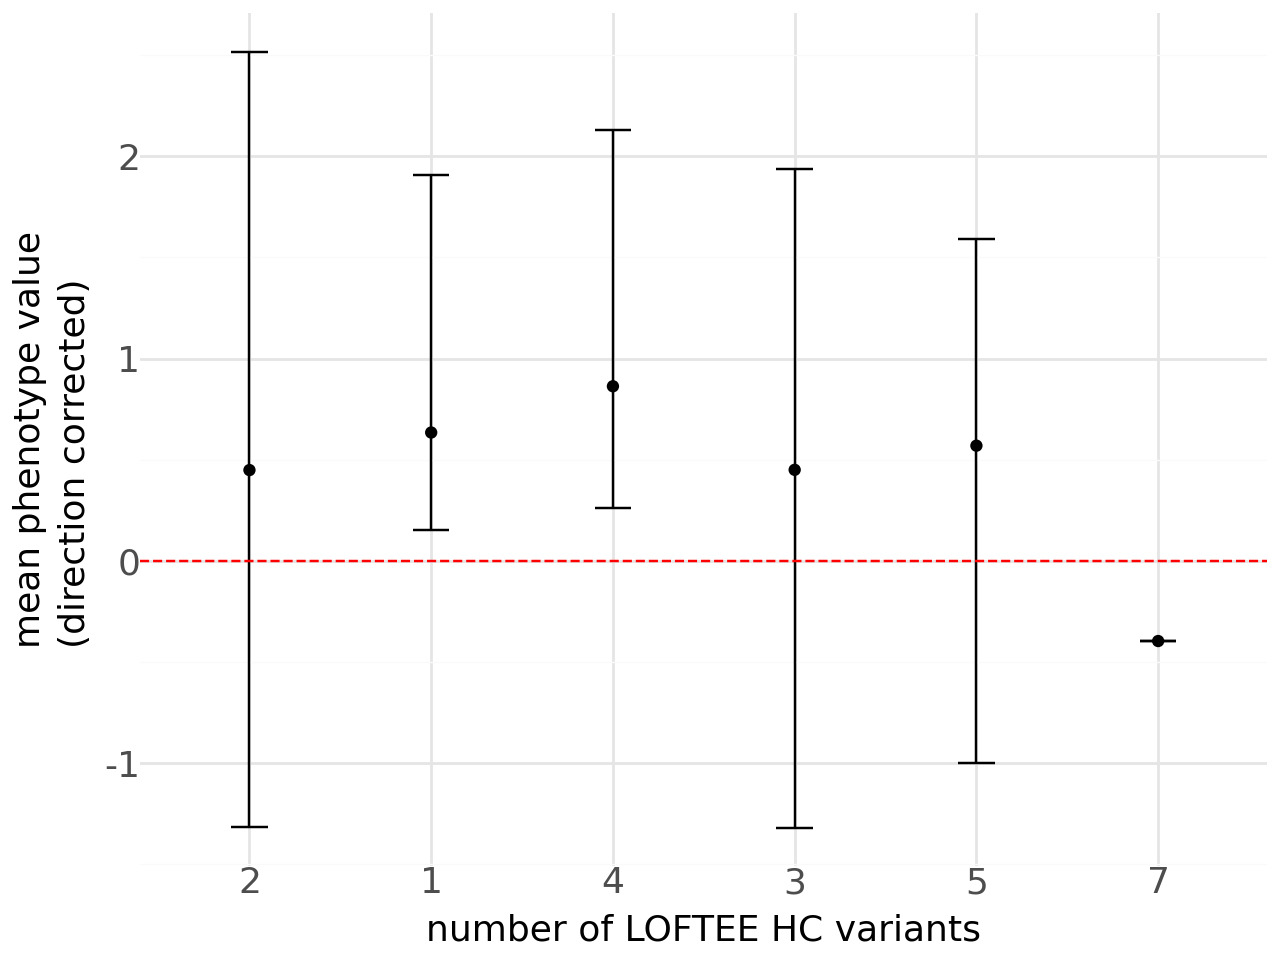

In [12]:
(
    ggplot(
        loftee_pheno_avg_region,
        aes(x='burden_categories', y='mean_pheno_value')
    )
    + geom_point(size=1.5)
    + geom_errorbar(aes(ymin='ci_quant_lower', ymax='ci_quant_upper'), width=0.2)
    + geom_hline(yintercept=0, linetype='dashed', color='red')
    + labs(
        x = 'number of LOFTEE HC variants',
        y = 'mean phenotype value\n(direction corrected)'
    )
    + theme_minimal()
    + theme(
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [13]:
loftee_pheno = (
    long_phenos_int
    .join(
        long_gt,
        on=['sample', 'region'],
        how='inner'
    )
    .with_columns(
        pheno_value_dircorr = pl.col('pheno_value_int')*pl.col('loftee_corr_dir'),
        burden_categories = pl.col('burden').cast(pl.Utf8).cast(pl.Categorical)
    )
)

loftee_pheno

sample,phenotype,pheno_value_int,region,loftee_corr_dir,burden,pheno_value_dircorr,burden_categories
str,str,f64,str,f64,i32,f64,cat
"""1120411""","""leg_fat_percentage_left_int""",0.51349,"""ENSG00000174231""",-1.0,1,-0.51349,"""1"""
"""1211024""","""leg_fat_percentage_left_int""",-1.05378,"""ENSG00000173064""",1.0,1,-1.05378,"""1"""
"""1270864""","""leg_fat_percentage_left_int""",-1.252097,"""ENSG00000174231""",-1.0,1,1.252097,"""1"""
"""1302862""","""leg_fat_percentage_left_int""",-0.941412,"""ENSG00000174231""",-1.0,1,0.941412,"""1"""
"""1328449""","""leg_fat_percentage_left_int""",2.259153,"""ENSG00000134294""",1.0,1,2.259153,"""1"""
…,…,…,…,…,…,…,…
"""5783310""","""mean_sphered_cell_volume_int""",-0.463114,"""ENSG00000134183""",1.0,1,-0.463114,"""1"""
"""5810303""","""mean_sphered_cell_volume_int""",-0.57968,"""ENSG00000197969""",-1.0,1,0.57968,"""1"""
"""5850324""","""mean_sphered_cell_volume_int""",-0.073021,"""ENSG00000197969""",-1.0,1,0.073021,"""1"""


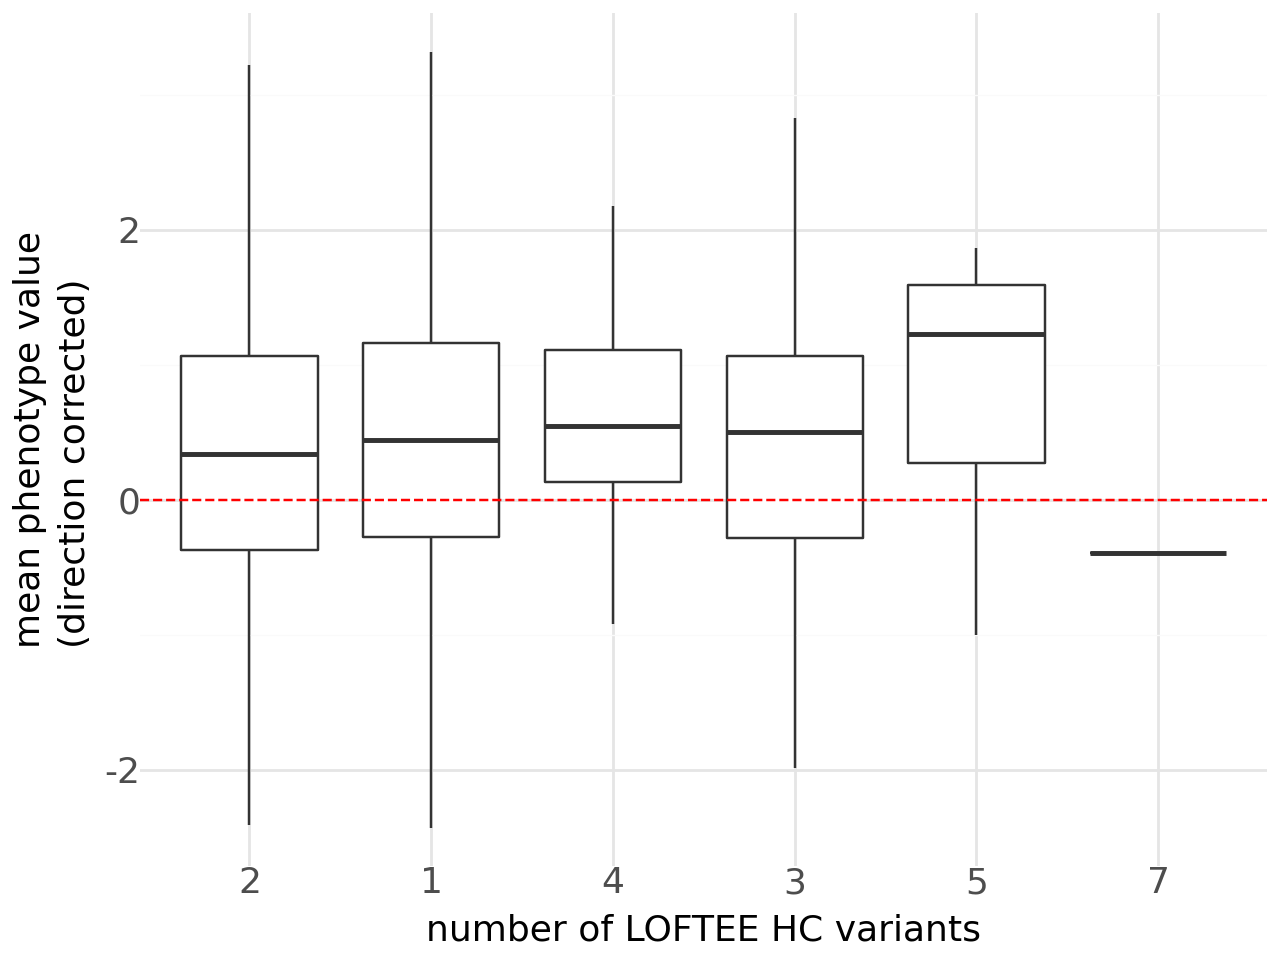

In [14]:
(
    ggplot(
        loftee_pheno, 
        # loftee_pheno.filter(pl.col('burden')==1), 
        aes(x='burden_categories', y='pheno_value_dircorr')
    )
    + geom_boxplot(outlier_shape=None)
    + geom_hline(yintercept=0, linetype='dashed', color='red')
    + labs(
        x = 'number of LOFTEE HC variants',
        y = 'mean phenotype value\n(direction corrected)'
    )
    + theme_minimal()
    + theme(
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [15]:
loftee_pheno_avg = (
    loftee_pheno
    .group_by(['burden_categories'])
    .agg(
        n_individuals = pl.len().cast(pl.Int32),
        mean_pheno_value = pl.col('pheno_value_dircorr').mean().cast(pl.Float32),
        std_pheno_value = pl.col('pheno_value_dircorr').std().cast(pl.Float32),
        ci_quant_lower = pl.col('pheno_value_dircorr').quantile(0.025).cast(pl.Float32),
        ci_quant_upper = pl.col('pheno_value_dircorr').quantile(0.975).cast(pl.Float32),
    )
    .with_columns(
        se_pheno_value = pl.col('std_pheno_value') / pl.col('n_individuals').sqrt(),
        ci_se_lower = pl.col('mean_pheno_value') - 1.96 * (pl.col('std_pheno_value') / pl.col('n_individuals').sqrt()),
        ci_se_upper = pl.col('mean_pheno_value') + 1.96 * (pl.col('std_pheno_value') / pl.col('n_individuals').sqrt())
    )
)

loftee_pheno_avg

burden_categories,n_individuals,mean_pheno_value,std_pheno_value,ci_quant_lower,ci_quant_upper,se_pheno_value,ci_se_lower,ci_se_upper
cat,i32,f32,f32,f32,f32,f64,f64,f64
"""3""",168,0.382869,1.129064,-1.895261,2.55736,0.087109,0.212135,0.553603
"""2""",961,0.356733,1.125556,-1.873744,2.51763,0.036308,0.285569,0.427897
"""5""",7,0.829798,1.088355,-1.000978,1.863754,0.411359,0.023533,1.636062
"""1""",74789,0.448126,1.070348,-1.637177,2.567491,0.003914,0.440454,0.455797
"""7""",1,-0.396249,null,-0.396249,-0.396249,null,null,null
"""4""",31,0.632257,0.993812,-0.89248,2.619945,0.178494,0.282409,0.982105


In [18]:
loftee_pheno_avg.write_parquet(f'{LOCAL_DIR}/LOFTEE_avg_effect_pheno_burdens.parquet')
!dx upload {LOCAL_DIR}/LOFTEE_avg_effect_pheno_burdens.parquet --path project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/LOFTEE_avg_effect/

[===========================================================>] Uploaded 3,454 of 3,454 bytes (100%) /home/dnanexus/data_dir//LOFTEE_avg_effect_pheno_burdens.parquet
ID                                file-J6P2xkQJg0y3036jx0PXq9Pj
Class                             file
Project                           project-Gyp4fvjJg0yFZ374KvP9bGFJ
Folder                            /processed_data/ukbgym/LOFTEE_avg_effect
Name                              LOFTEE_avg_effect_pheno_burdens.parquet
State                             closing
Visibility                        visible
Types                             -
Properties                        -
Tags                              -
Outgoing links                    -
Created                           Tue Feb 24 23:06:14 2026
Created by                        shubhankar
 via the job                      job-J6P2Y68Jg0y8Z7y3806PXzQY
Last modified                     Tue Feb 24 23:06:14 2026
Media type                        
archivalState              

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 1 rows containing missing values.


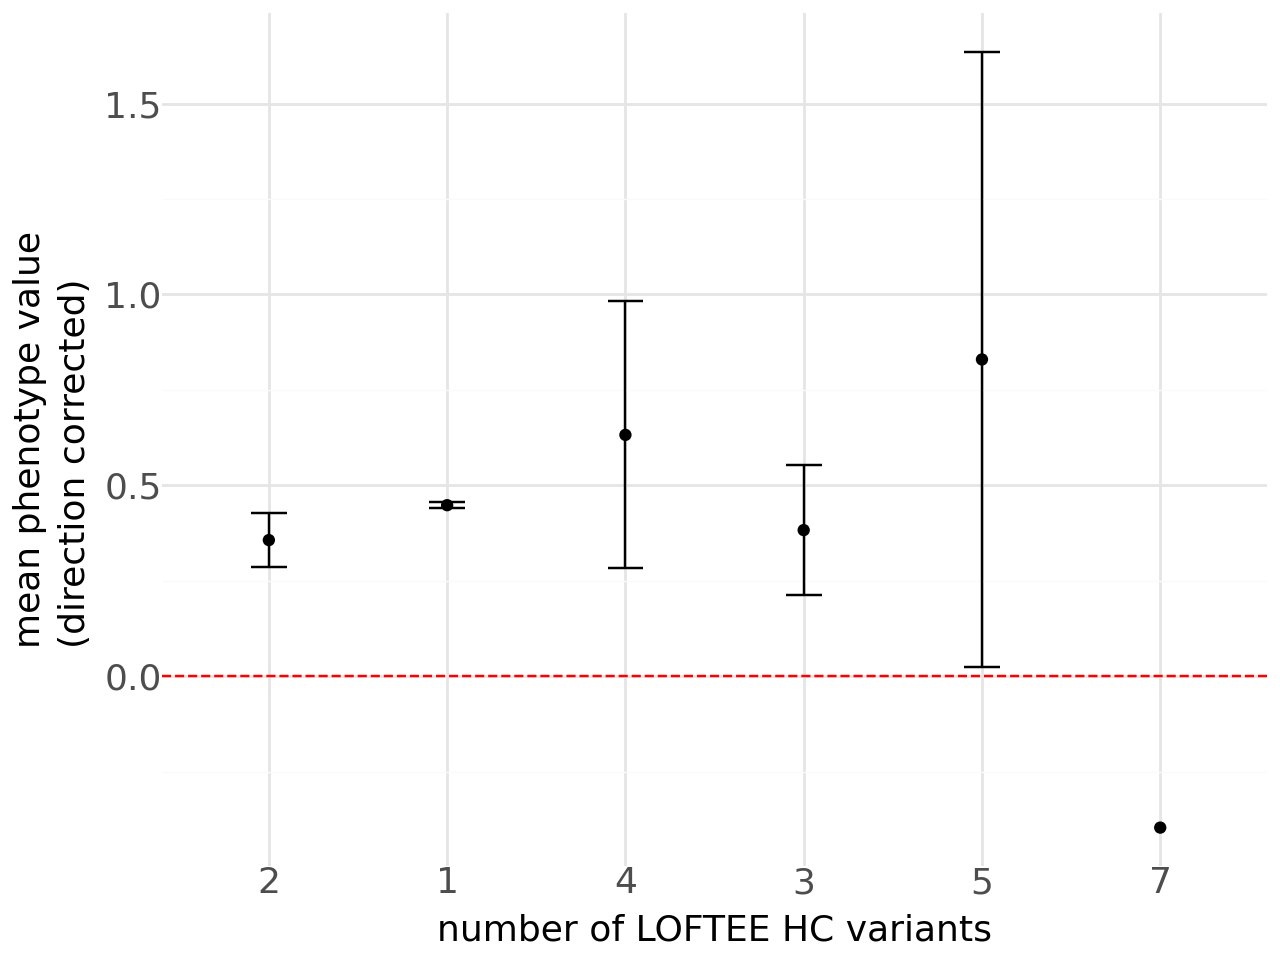

In [17]:
(
    ggplot(
        loftee_pheno_avg,
        aes(x='burden_categories', y='mean_pheno_value')
    )
    + geom_point(size=1.5)
    # + geom_errorbar(aes(ymin='ci_quant_lower', ymax='ci_quant_upper'), width=0.2)
    + geom_errorbar(aes(ymin='ci_se_lower', ymax='ci_se_upper'), width=0.2)
    + geom_hline(yintercept=0, linetype='dashed', color='red')
    + labs(
        x = 'number of LOFTEE HC variants',
        y = 'mean phenotype value\n(direction corrected)'
    )
    + theme_minimal()
    + theme(
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)